# 06 · Interpretabilidade e aplicação estratégica

Os notebooks anteriores entregaram três coisas: um modelo que prevê se o aluno será alfabetizado, um modelo de risco municipal com projeção para 2026 e quatro perfis de município. Este notebook abre os modelos com SHAP e usa tudo isso para responder, uma a uma, às cinco perguntas estratégicas do desafio:

1. Quais fatores mais impactam a alfabetização?
2. Quais municípios apresentam maior risco educacional?
3. Quais regiões possuem padrões semelhantes?
4. Como prever municípios que podem não atingir metas futuras?
5. Quais variáveis possuem maior influência nos modelos?

O SHAP (valores de Shapley aplicados a modelos) atribui a cada variável a contribuição marginal média para cada previsão. É exato para modelos de árvore (TreeExplainer) e tem as propriedades que fazem dele a referência para explicação: as contribuições somam a diferença entre a previsão e a média, e variáveis com o mesmo efeito recebem o mesmo crédito. Todos os gráficos usam rótulos de negócio no lugar dos nomes técnicos.

In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from src.data.abt import carregar_abt_aluno
from src.preprocessing.features import grupos_aluno, grupos_municipio, preparar_xy
from src.modeling.train import carregar_modelo
from src.evaluation.interpretabilidade import explicar, importancia_shap, importancia_por_grupo, importancia_permutacao
from src.visualization.estilo import aplicar_estilo, salvar, fmt_pct, AZUL, LARANJA, CINZA, VERDE, VERMELHO, PALETA, CORES_REGIAO
from src.visualization.mapas import carregar_malha, mapa_municipios
from src.visualization.rotulos import rotulo

aplicar_estilo()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
SEED = 42

modelo_aluno = carregar_modelo("modelo_aluno")
modelo_municipio = carregar_modelo("modelo_municipio")
meta_aluno = json.loads(Path("models/modelo_aluno.json").read_text(encoding="utf-8"))
meta_municipio = json.loads(Path("models/modelo_municipio.json").read_text(encoding="utf-8"))
print("aluno:", meta_aluno["modelo"], "| município:", meta_municipio["modelo"])

aluno: lightgbm | município: lightgbm


/home/cosme/Desktop/ai-scientist-masters/phase-03/tech-challenge/repo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. O que pesa no modelo do aluno

O SHAP é calculado em uma amostra de 5 mil alunos de 2025 (o conjunto de teste, para explicar o comportamento do modelo em dado novo).

In [2]:
alunos = carregar_abt_aluno()
teste = alunos[alunos["ano"] == 2025]
ga = grupos_aluno()
x_teste, y_teste = preparar_xy(teste, ga, "alfabetizado")
shap_aluno, xt_aluno = explicar(modelo_aluno, x_teste, max_amostras=5000, seed=SEED)
imp_aluno = importancia_shap(shap_aluno)
imp_aluno.head(15).round(4)

,variavel,importancia_shap
0,% alfabetizados no ano anterior,0.1956
1,Salto necessário para a meta (p.p.),0.1413
2,Presença na prova na escola (%),0.1157
3,IDEB anos iniciais (última edição),0.1021
4,Nota de português no Saeb 5o ano (última edição),0.0683
5,UF: RS,0.0530
6,UF: MG,0.0485
7,UF: BA,0.0378
8,UF: SP,0.0340
9,Rede de ensino: estadual,0.0246


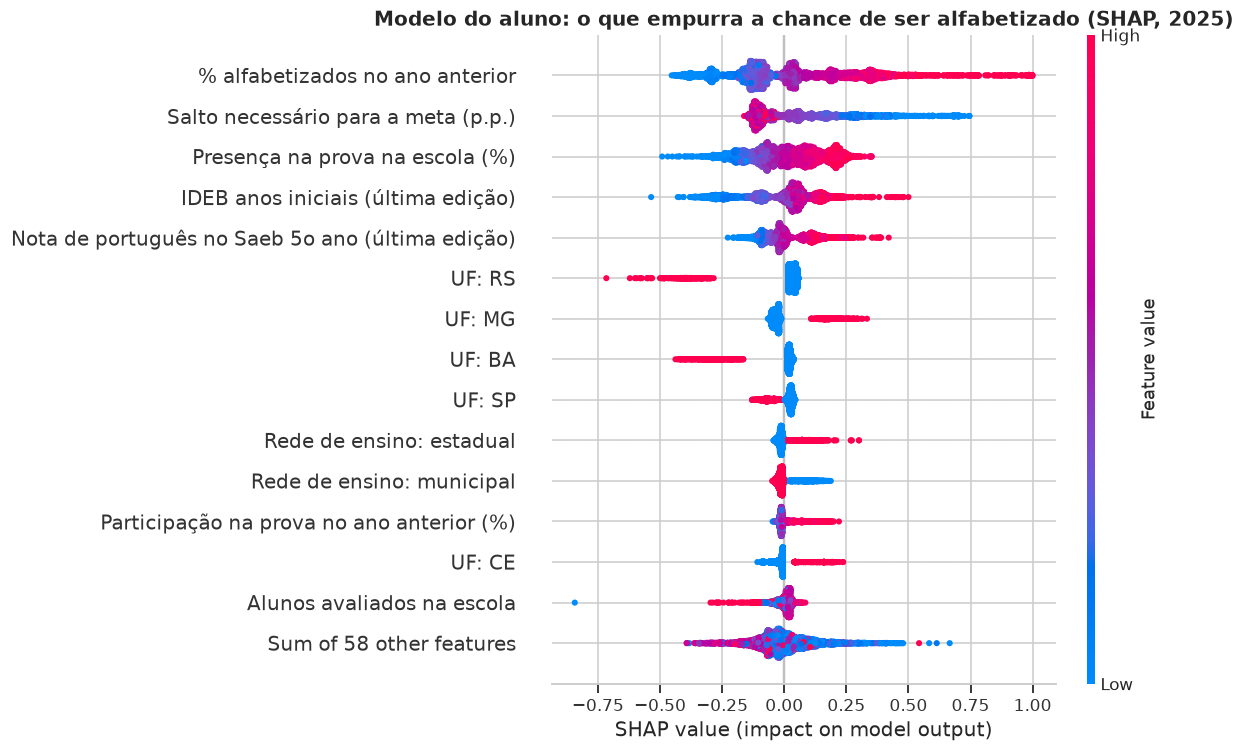

In [3]:
fig = plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_aluno, max_display=15, show=False)
plt.title("Modelo do aluno: o que empurra a chance de ser alfabetizado (SHAP, 2025)")
plt.gcf().set_size_inches(11, 7)
salvar(plt.gcf(), "06_shap_aluno_beeswarm")
plt.show()

In [4]:
bloco_aluno = importancia_por_grupo(imp_aluno, {"histórico do indicador": ga["historico"], "porte e tamanho": ga["log"], "contexto (censo, rendimento, ideb, socioeconômico, escola)": ga["numericas"]})
bloco_aluno

,% da importância
bloco,
"contexto (censo, rendimento, ideb, socioeconômico, escola)",40.2
histórico do indicador,30.9
territorio (UF) e rede,24.9
porte e tamanho,4.1


No grão de aluno, a variável que mais move a previsão é o **histórico do município** (o percentual do ano anterior), seguida do **salto necessário para a meta**, da **presença na prova na escola**, do **IDEB** e da **UF**. Somando por bloco, o contexto (Censo Escolar, rendimento, IDEB, socioeconômico e escola) pesa 40%, o histórico 31% e UF e rede 25%. A leitura de política: a probabilidade de uma criança ser alfabetizada é, antes de tudo, uma propriedade da rede em que ela estuda, e o sinal mais barato de acompanhar é a frequência à prova, que reflete a frequência à escola.

### 1.1 Variante para uso antes da prova

Duas variáveis do modelo do aluno são medidas no dia da prova: a presença na prova na escola e o número de alunos avaliados na escola. Elas não são derivadas do resultado (não é vazamento do alvo), mas só existem quando a prova acontece, então o modelo completo serve para explicar o resultado depois da aplicação, não para triagem antes do ano letivo. Para essa segunda finalidade, a variante abaixo usa só variáveis conhecidas antes da prova: rede, UF e o contexto municipal. Mesmos hiperparâmetros, mesmo treino em 2024 com pesos, mesmo teste em 2025.

In [5]:
from lightgbm import LGBMClassifier
from sklearn.base import clone

from src.preprocessing.pipeline import build_pipeline
from src.evaluation.metricas import avaliar_classificacao

treino = alunos[alunos["ano"] == 2024]
ga_antes = {
    "historico": ga["historico"],
    "log": [c for c in ga["log"] if c != "escola_qtd_avaliados"],
    "numericas": [c for c in ga["numericas"] if c != "escola_taxa_presenca"],
    "categoricas": ga["categoricas"],
}
hiper = meta_aluno["hiperparametros"]
x_tr_a, y_tr_a = preparar_xy(treino, ga_antes, "alfabetizado")
modelo_antes = build_pipeline(ga_antes, LGBMClassifier(n_estimators=600, learning_rate=0.03, random_state=SEED, n_jobs=-1, verbose=-1, **hiper))
modelo_antes.fit(x_tr_a, y_tr_a, modelo__sample_weight=treino["peso"].values)
x_te_a, y_te_a = preparar_xy(teste, ga_antes, "alfabetizado")
proba_antes = modelo_antes.predict_proba(x_te_a)[:, 1]
proba_completo = modelo_aluno.predict_proba(x_teste)[:, 1]
w_te = teste["peso"].values
comparacao_variantes = pd.DataFrame({
    "completo (com presença e tamanho da escola)": avaliar_classificacao(y_teste.values, proba_completo, meta_aluno["limiar_operacao"], w_te),
    "antes da prova (sem as variáveis de escola)": avaliar_classificacao(y_te_a.values, proba_antes, meta_aluno["limiar_operacao"], w_te),
}).T[["auc_roc", "auc_pr", "recall_negativos", "precisao_negativos", "acuracia"]]
comparacao_variantes.round(3)

,auc_roc,auc_pr,recall_negativos,precisao_negativos,acuracia
completo (com presença e tamanho da escola),0.646,0.776,0.689,0.428,0.577
antes da prova (sem as variáveis de escola),0.641,0.772,0.668,0.426,0.577


Sem as duas variáveis de escola o AUC no teste de 2025 cai pouco: o modelo perde a informação de frequência, que é o sinal mais forte no nível da escola, mas mantém a ordenação pelo contexto municipal. Para triagem antes do ano letivo é esta variante que deve ser usada, com o limiar reestimado; para leitura do resultado depois da prova, a completa. A distinção fica registrada no README e nas decisões analíticas.

## 2. O que pesa no modelo do município

O modelo de município prevê o nível do indicador (o percentual de alfabetizados), e o risco vem da comparação com a meta. O SHAP aqui explica o nível previsto para 2026, em pontos percentuais.

In [6]:
abt = pd.read_parquet("data/processed/abt_municipio.parquet")
proj = abt[(abt["ano_alvo"] == 2026) & abt["meta_t"].notna()].copy()
gm = grupos_municipio()
x_proj, _ = preparar_xy(proj.assign(atingiu_meta_t=0), gm, "atingiu_meta_t")
shap_mun, xt_mun = explicar(modelo_municipio, x_proj, max_amostras=len(x_proj), seed=SEED)
imp_mun = importancia_shap(shap_mun)
imp_mun.head(15).round(3)

,variavel,importancia_shap
0,% alfabetizados no ano anterior,6.441
1,IDEB anos iniciais (última edição),1.721
2,UF: SP,1.249
3,UF: RS,1.215
4,Participação na prova no ano anterior (%),0.951
5,Salto necessário para a meta (p.p.),0.882
6,População (Censo 2022),0.681
7,Nota de português no Saeb 5o ano (última edição),0.676
8,IDEB anos iniciais (edição anterior),0.667
9,"Taxa de abandono, anos iniciais (%)",0.629


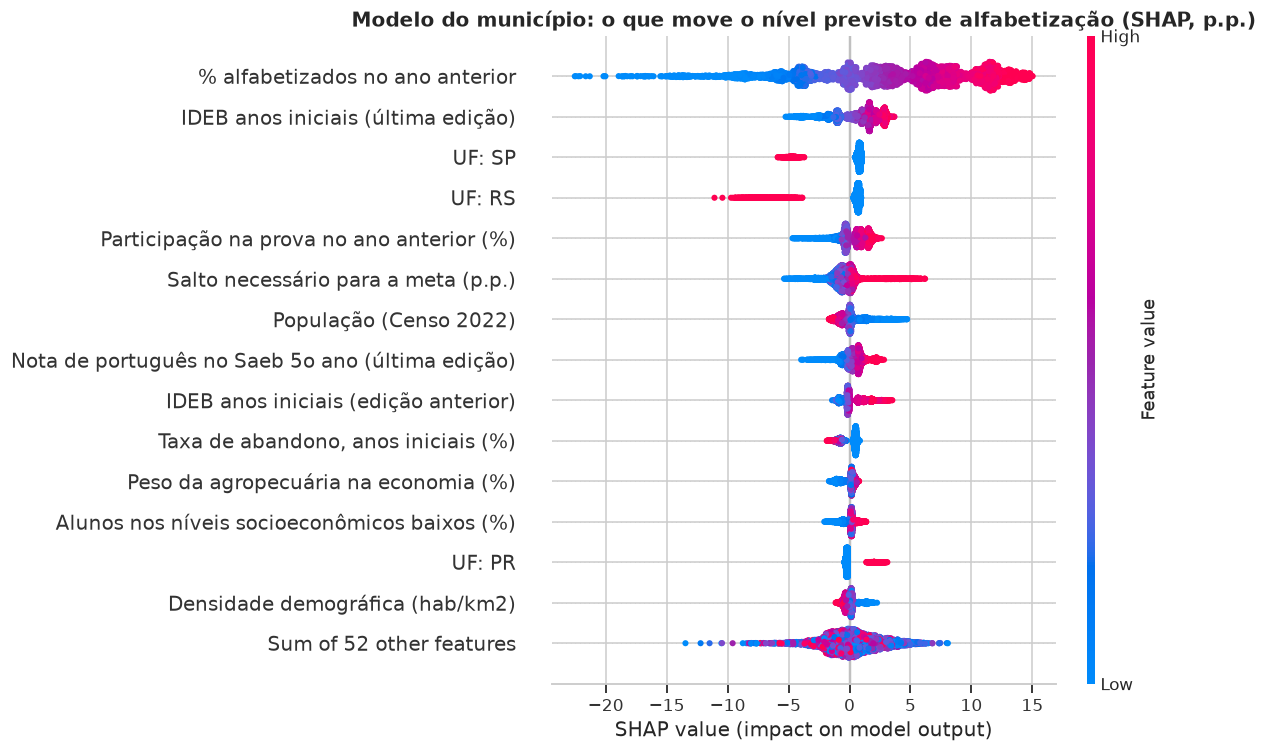

In [7]:
fig = plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_mun, max_display=15, show=False)
plt.title("Modelo do município: o que move o nível previsto de alfabetização (SHAP, p.p.)")
plt.gcf().set_size_inches(11, 7)
salvar(plt.gcf(), "06_shap_municipio_beeswarm")
plt.show()

In [8]:
bloco_mun = importancia_por_grupo(imp_mun, {"histórico do indicador": gm["historico"], "porte e renda": gm["log"], "censo escolar, rendimento, ideb e socioeconômico": gm["numericas"]})
bloco_mun

,% da importância
bloco,
histórico do indicador,37.9
"censo escolar, rendimento, ideb e socioeconômico",34.0
territorio (UF) e rede,20.5
porte e renda,7.6


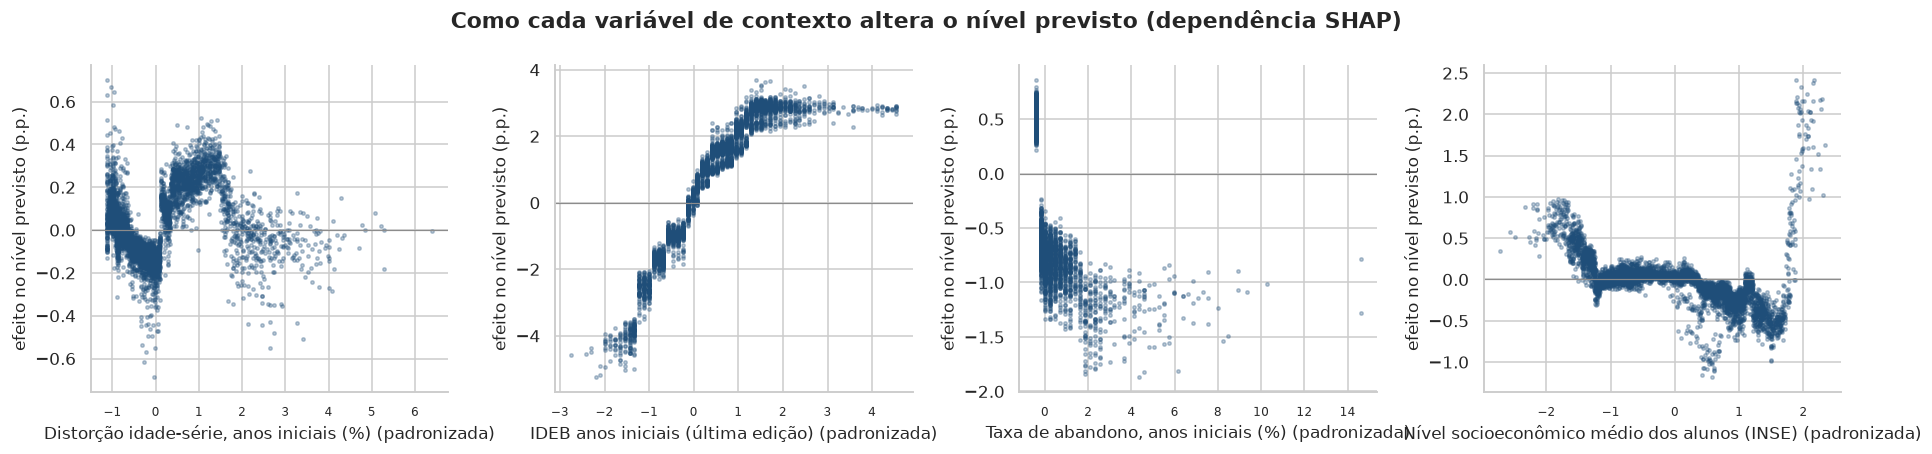

In [9]:
# dependencia parcial via SHAP para as variaveis de contexto mais fortes
nomes = list(shap_mun.feature_names)
candidatas = [rotulo(c) for c in ["distorcao_ai_pct", "ideb_ultimo", "abandono_ai_pct", "inse_medio"]]
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, nome in zip(axes, candidatas):
    j = nomes.index(nome)
    ax.scatter(xt_mun.iloc[:, j], shap_mun.values[:, j], s=5, alpha=0.3, color=AZUL)
    ax.axhline(0, color=CINZA, lw=0.8)
    ax.set_xlabel(nome + " (padronizada)")
    ax.set_ylabel("efeito no nível previsto (p.p.)")
    ax.tick_params(axis="x", labelsize=8)
fig.suptitle("Como cada variável de contexto altera o nível previsto (dependência SHAP)", fontweight="bold")
salvar(fig, "06_shap_dependencia")
plt.show()

As curvas de dependência mostram o que a importância média esconde. O IDEB tem efeito forte e monotônico, de −4 a +3 pontos no nível previsto, com saturação nos extremos. O abandono funciona como um degrau: abandono zero nos anos iniciais vale meio ponto a mais; qualquer abandono custa cerca de um ponto, e não importa muito quanto. Distorção idade-série e INSE, que na EDA tinham correlação clara com o resultado, pesam pouco dentro do modelo (menos de um ponto), porque o histórico e o IDEB já carregam essa informação; é o efeito da colinearidade que a matriz de correlação antecipava. A leitura para o gestor: distorção e abandono continuam bons sinais de alerta, mas o que o modelo usa para prever é o resultado passado da rede.

In [10]:
# importancia por permutacao (segunda opiniao, sobre as colunas originais e o AUC do risco derivado nao se aplica; usa-se o erro do nivel)
com_alvo = abt[abt["atingiu_meta_t"].notna()]
x_val, _ = preparar_xy(com_alvo, gm, "atingiu_meta_t")
perm = importancia_permutacao(modelo_municipio, x_val, com_alvo["indicador_t"].astype(float).values, n_repeats=5, seed=SEED, scoring="neg_mean_absolute_error")
perm = perm.rename(columns={"queda_auc": "aumento_do_erro_pp"})
perm.head(12).round(3)

,variavel,aumento_do_erro_pp,desvio
0,% alfabetizados no ano anterior,4.715,0.044
1,UF,1.137,0.024
2,IDEB anos iniciais (última edição),0.615,0.022
3,Participação na prova no ano anterior (%),0.398,0.024
4,Nota de português no Saeb 5o ano (última edição),0.220,0.013
5,Salto necessário para a meta (p.p.),0.207,0.012
6,População (Censo 2022),0.187,0.012
7,IDEB anos iniciais (edição anterior),0.096,0.008
8,"Taxa de aprovação, anos iniciais (%)",0.088,0.002
9,"Taxa de abandono, anos iniciais (%)",0.069,0.006


## 3. Explicação local: por que este município está em risco

Para o gestor, a explicação global é menos útil do que a explicação do seu município. O gráfico em cascata mostra, para um município no topo da lista de risco de 2026, como cada variável move a previsão a partir da média nacional. E o contraste com um município do perfil consolidado mostra o que separa os dois.

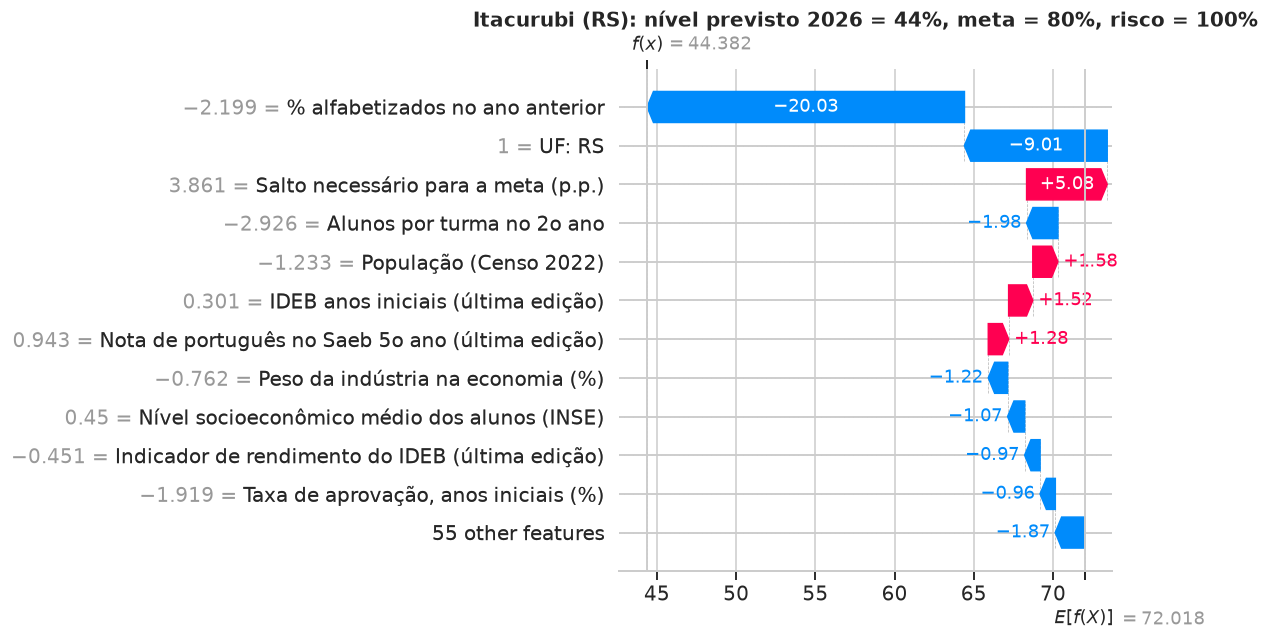

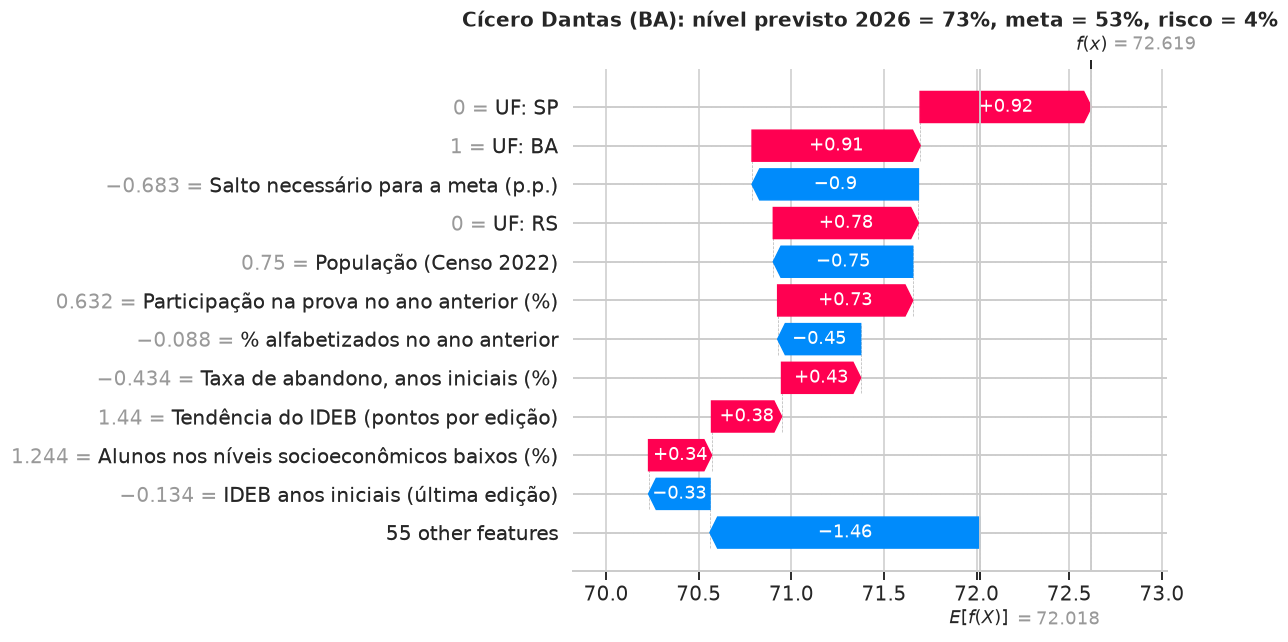

In [11]:
ranking = pd.read_csv("reports/municipios_risco_2026.csv")
alvo_risco = ranking.iloc[0]
alvo_ok = ranking[ranking["risco_2026"] < 0.05].iloc[0]
pos_risco = np.where(proj["id_municipio"].values == alvo_risco["id_municipio"])[0][0]
pos_ok = np.where(proj["id_municipio"].values == alvo_ok["id_municipio"])[0][0]

for pos, m, nome_fig in [(pos_risco, alvo_risco, "06_shap_local_risco"), (pos_ok, alvo_ok, "06_shap_local_consolidado")]:
    fig = plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_mun[pos], max_display=12, show=False)
    plt.title(f"{m['nome_municipio']} ({m['sigla_uf']}): nível previsto 2026 = {m['nivel_previsto_2026']:.0f}%, meta = {m['meta_2026']:.0f}%, risco = {100 * m['risco_2026']:.0f}%")
    plt.gcf().set_size_inches(11, 6)
    salvar(plt.gcf(), nome_fig)
    plt.show()

## 4. Respostas às perguntas estratégicas

### 4.1 Quais fatores mais impactam a alfabetização?

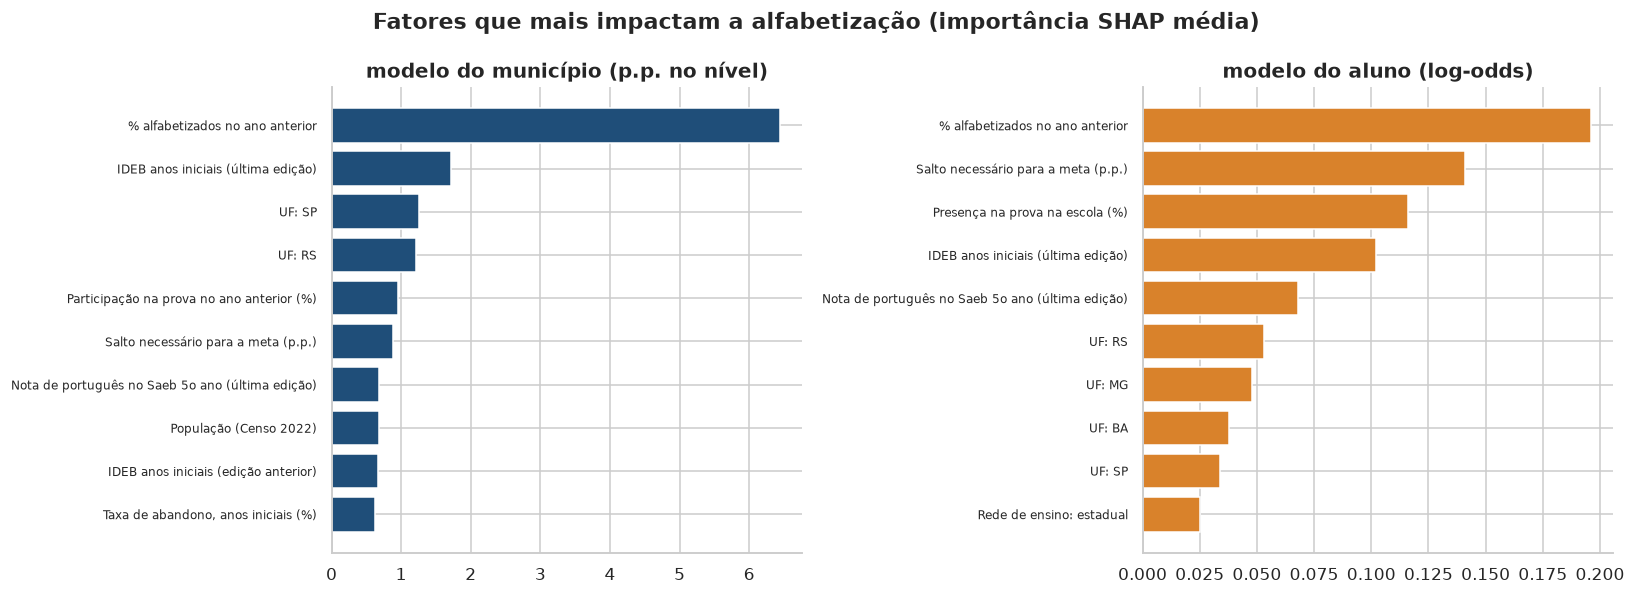

In [12]:
top_mun = imp_mun.head(10).copy()
top_mun["importancia_shap"] = top_mun["importancia_shap"].round(2)
top_alu = imp_aluno.head(10).copy()
top_alu["importancia_shap"] = top_alu["importancia_shap"].round(3)
fatores = pd.concat({"modelo do município (p.p. no nível)": top_mun.set_index("variavel")["importancia_shap"], "modelo do aluno (log-odds)": top_alu.set_index("variavel")["importancia_shap"]}, axis=1)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, (titulo, serie), cor in zip(axes, fatores.items(), [AZUL, LARANJA]):
    s = serie.dropna().sort_values()
    ax.barh(s.index, s.values, color=cor)
    ax.set_title(titulo)
    ax.tick_params(axis="y", labelsize=8)
fig.suptitle("Fatores que mais impactam a alfabetização (importância SHAP média)", fontweight="bold")
salvar(fig, "06_fatores")
plt.show()

Resposta: nos dois grãos, o **histórico da rede** vem primeiro (o percentual do ano anterior e, no aluno, o salto necessário para a meta); depois o **IDEB dos anos iniciais** com a nota de português do 5º ano, a **UF** e a **participação na prova**. O fluxo escolar entra pelo abandono, com efeito de degrau, e pela distorção, com efeito pequeno; o porte do município aparece com sinal negativo (municípios menores alfabetizam mais). O contexto socioeconômico (INSE, PIB per capita) pesa menos do que se costuma supor, porque redes bem geridas alfabetizam mesmo em contextos pobres. E a UF continua sendo um fator em si, o que aponta para o papel do regime de colaboração estadual e para a diferença entre os instrumentos de avaliação.

### 4.2 Quais municípios apresentam maior risco educacional?

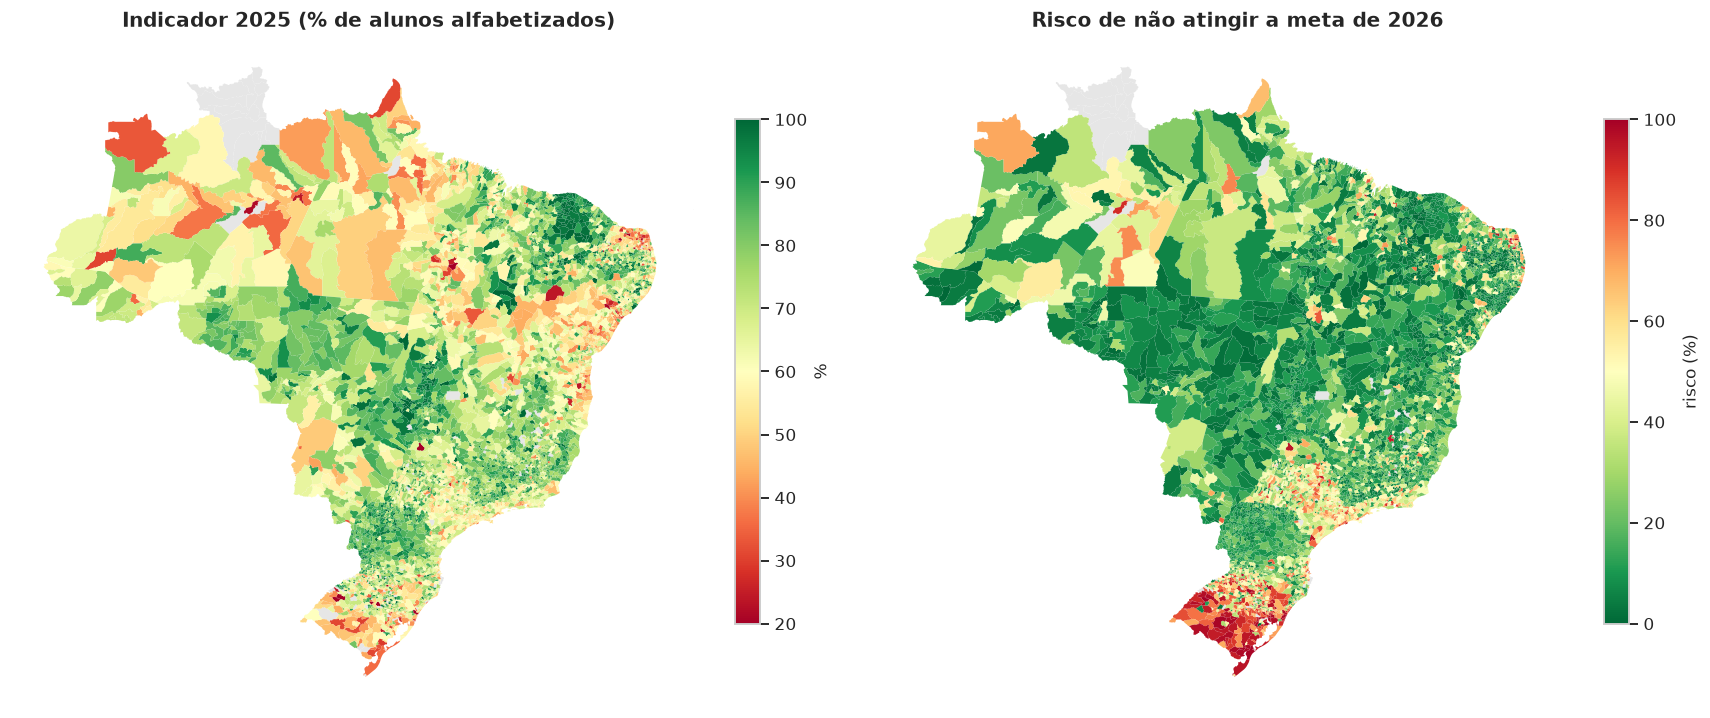

In [13]:
malha = carregar_malha()
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
mapa_municipios(ranking.set_index("id_municipio")["indicador_2025"].to_dict(), malha, ax=axes[0], cmap="RdYlGn", vmin=20, vmax=100, titulo="Indicador 2025 (% de alunos alfabetizados)", rotulo_barra="%")
mapa_municipios(ranking.set_index("id_municipio")["risco_2026"].mul(100).to_dict(), malha, ax=axes[1], cmap="RdYlGn_r", vmin=0, vmax=100, titulo="Risco de não atingir a meta de 2026", rotulo_barra="risco (%)")
salvar(fig, "06_mapa_risco")
plt.show()

In [14]:
colunas_lista = ["posicao", "nome_municipio", "sigla_uf", "indicador_2025", "meta_2026", "nivel_previsto_2026", "risco_2026", "distorcao_ai_pct", "ideb_ultimo"]
lista = ranking[colunas_lista].head(25).copy()
lista.columns = ["posição", "município", "UF", "indicador 2025 (%)", "meta 2026 (%)", "previsto 2026 (%)", "risco", rotulo("distorcao_ai_pct"), rotulo("ideb_ultimo")]
lista.round(2)

,posição,município,UF,indicador 2025 (%),meta 2026 (%),previsto 2026 (%),risco,"Distorção idade-série, anos iniciais (%)",IDEB anos iniciais (última edição)
0,1,Itacurubi,RS,20.59,80.00,44.38,1.00,6.1,6.1
1,2,Barra do Ribeiro,RS,37.81,73.90,45.78,0.99,9.5,5.4
2,3,São Pedro das Missões,RS,NaN,80.00,52.34,0.99,4.5,NaN
3,4,Amaral Ferrador,RS,24.62,74.91,48.18,0.99,7.4,5.3
4,5,Esmeralda,RS,35.56,80.00,53.91,0.99,5.2,5.9
5,6,Pedro Osório,RS,36.84,73.44,47.52,0.99,14.2,5.6
6,7,Cerrito,RS,53.70,77.28,51.69,0.99,8.5,5.4
7,8,Rio Grande,RS,35.73,66.59,41.18,0.99,15.7,5.5
8,9,Passo Fundo,RS,39.33,68.81,45.44,0.99,11.8,5.7
9,10,São Gabriel,RS,44.20,70.12,46.81,0.99,14.8,5.6


Resposta: a lista completa está em `reports/municipios_risco_2026.csv`, ordenada pelo risco. O mapa da esquerda mostra onde a alfabetização está baixa hoje; o da direita mostra onde a meta de 2026 tende a não ser atingida. Os dois não coincidem totalmente: municípios com nível baixo mas meta modesta ficam fora da lista de risco, e municípios com nível médio e meta ambiciosa entram. É a diferença entre "quem está mal" e "quem vai ficar aquém do combinado", e a política pública precisa das duas leituras.

### 4.3 Quais regiões possuem padrões semelhantes?

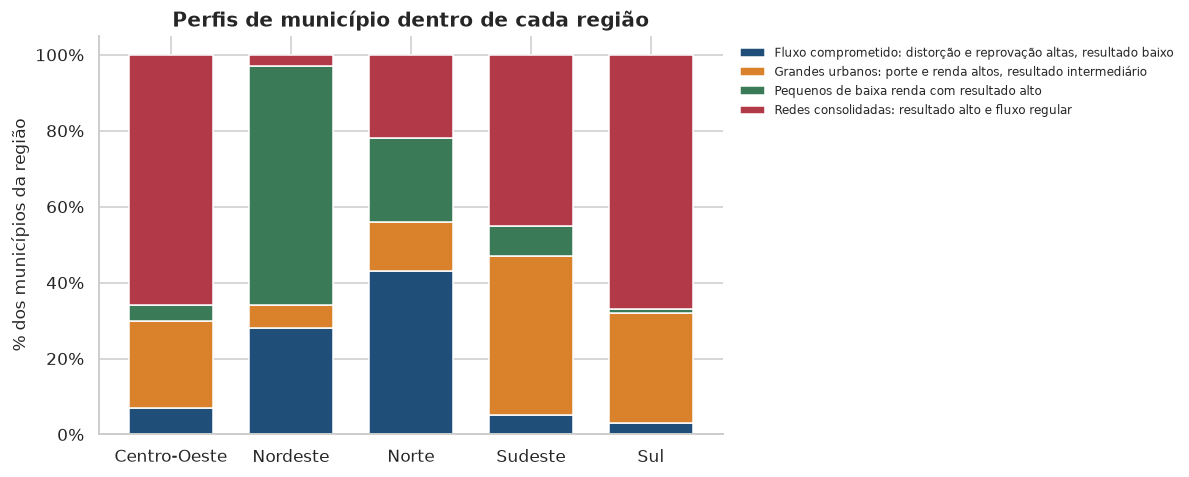

nome_regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul,total
perfil,,,,,,
"Fluxo comprometido: distorção e reprovação altas, resultado baixo",32,501,193,75,37,838
"Grandes urbanos: porte e renda altos, resultado intermediário",109,101,58,693,337,1298
Pequenos de baixa renda com resultado alto,17,1134,99,126,10,1386
Redes consolidadas: resultado alto e fluxo regular,309,57,99,743,793,2001


In [15]:
perfis = pd.read_csv("reports/perfis_municipios.csv")
comp = pd.crosstab(perfis["perfil"], perfis["nome_regiao"])
comp["total"] = comp.sum(axis=1)
comp_pct = pd.crosstab(perfis["perfil"], perfis["nome_regiao"], normalize="columns").mul(100).round(0)
fig, ax = plt.subplots(figsize=(11, 4.5))
comp_pct.T.plot.bar(stacked=True, ax=ax, color=PALETA[: len(comp_pct)], width=0.7)
ax.set_ylabel("% dos municípios da região")
ax.set_xlabel("")
ax.set_title("Perfis de município dentro de cada região")
ax.legend(title="", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.tick_params(axis="x", rotation=0)
fmt_pct(ax, "y")
salvar(fig, "06_perfis_por_regiao")
plt.show()
comp

Resposta: os perfis (notebook 05) cortam as regiões. O perfil de fluxo comprometido concentra-se no Norte e no Nordeste, mas todo o país tem municípios nele; o perfil consolidado inclui boa parte do Nordeste (Ceará, Piauí, Paraíba). "Padrões semelhantes" são grupos de condições, não macrorregiões, e a matriz perfil x risco em `reports/perfis_municipios.csv` é o instrumento para tratar municípios parecidos com a mesma estratégia.

### 4.4 Como prever municípios que podem não atingir metas futuras?

In [16]:
uf_risco = ranking.groupby("sigla_uf").agg(municipios=("id_municipio", "size"), em_risco=("risco_2026", lambda s: int((s >= 0.5).sum())), risco_medio=("risco_2026", "mean"), salto_mediano=("salto_necessario_pp", "median")).sort_values("risco_medio", ascending=False)
uf_risco["% em risco"] = (100 * uf_risco["em_risco"] / uf_risco["municipios"]).round(0)
backtest = meta_municipio["backtest_2024_para_2025"]
print(f"backtest 2024 -> 2025: AUC do risco = {backtest['auc_risco_teste_2025']:.3f}, Spearman do nível = {backtest['spearman_teste_2025']:.2f}, viés do nível = {backtest['vies_teste_2025']:.1f} p.p.")
uf_risco.round(2)

backtest 2024 -> 2025: AUC do risco = 0.772, Spearman do nível = 0.69, viés do nível = -7.3 p.p.


,municipios,em_risco,risco_medio,salto_mediano,% em risco
sigla_uf,,,,,
RS,476,331,0.63,10.09,70.0
SP,629,262,0.46,2.12,42.0
RJ,92,33,0.42,2.95,36.0
AM,60,15,0.35,6.79,25.0
SC,284,70,0.35,0.96,25.0
RN,163,46,0.33,3.32,28.0
SE,75,17,0.29,2.81,23.0
MA,217,32,0.26,-4.46,15.0
PE,184,24,0.25,-2.92,13.0


Resposta: com o modelo de nível reajustado a cada ano e comparado com a meta do ano seguinte. O backtest de 2024 para 2025 mostra que o ranking se sustenta fora do tempo (AUC do risco próximo de 0,77), e que o erro típico é de nível, não de ordem, quando há um choque nacional como o de 2025. Para 2026, a tabela por UF mostra onde o número de municípios em risco é maior e qual o salto mediano exigido pela meta; para 2027 em diante, o mesmo fluxo roda com o dado novo (`make abt` e `make train`).

### 4.5 Quais variáveis possuem maior influência nos modelos?

In [17]:
influencia = pd.concat({
    "município (SHAP, p.p.)": imp_mun.set_index("variavel")["importancia_shap"].head(12),
    "município (permutação, +erro p.p.)": perm.set_index("variavel")["aumento_do_erro_pp"].head(12),
    "aluno (SHAP, log-odds)": imp_aluno.set_index("variavel")["importancia_shap"].head(12),
}, axis=1)
influencia.round(3)

,"município (SHAP, p.p.)","município (permutação, +erro p.p.)","aluno (SHAP, log-odds)"
variavel,,,
% alfabetizados no ano anterior,6.441,4.715,0.196
IDEB anos iniciais (última edição),1.721,0.615,0.102
UF: SP,1.249,NaN,0.034
UF: RS,1.215,NaN,0.053
Participação na prova no ano anterior (%),0.951,0.398,0.024
Salto necessário para a meta (p.p.),0.882,0.207,0.141
População (Censo 2022),0.681,0.187,NaN
Nota de português no Saeb 5o ano (última edição),0.676,0.220,0.068
IDEB anos iniciais (edição anterior),0.667,0.096,NaN


Resposta: as duas medidas (SHAP e permutação) concordam no topo: percentual do ano anterior, UF, IDEB, participação na prova, nota de português e salto necessário. A permutação, que mede o quanto o erro sobe quando a variável é embaralhada, confirma que o histórico é a variável da qual o modelo mais depende (o erro sobe quase 5 pontos sem ela), seguido da UF. A tabela completa fica em `reports/`.

In [18]:
Path("reports").mkdir(exist_ok=True)
imp_mun.round(4).to_csv("reports/importancia_shap_municipio.csv", index=False)
imp_aluno.round(4).to_csv("reports/importancia_shap_aluno.csv", index=False)
comparacao_variantes.round(4).to_csv("reports/modelo_aluno_variantes.csv")
perm.round(4).to_csv("reports/importancia_permutacao_municipio.csv", index=False)
uf_risco.round(3).to_csv("reports/risco_2026_por_uf.csv")
print("tabelas salvas em reports/")

tabelas salvas em reports/


## 5. Uma nota sobre causalidade

Tudo o que o SHAP diz é sobre o modelo, não sobre o mundo: "distorção idade-série alta reduz o nível previsto" não significa que reduzir a distorção por decreto elevaria a alfabetização. As variáveis de fluxo são sintomas de uma rede que retém e reprova, e a intervenção certa pode ser anterior (alfabetização no 1º ano, busca ativa, formação). Para estimar o efeito de uma intervenção seria preciso um desenho causal (pareamento por escore de propensão, diferenças em diferenças entre redes que adotaram e não adotaram um programa), que fica como evolução futura. O que o modelo entrega hoje é triagem e priorização com base em evidência.